## Prior Distribution Selection: Conjugate versus Jeffreys Priors

<>:159: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:159: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
C:\Users\Himanshu Saxena\AppData\Local\Temp\ipykernel_4156\633352049.py:159: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  bins=50, label=f'Jeffreys MCMC Samples ($\hat{{R}} = {r_hat_value:.4f}$)')


Gelman-Rubin diagnostic (R-hat): 1.000273


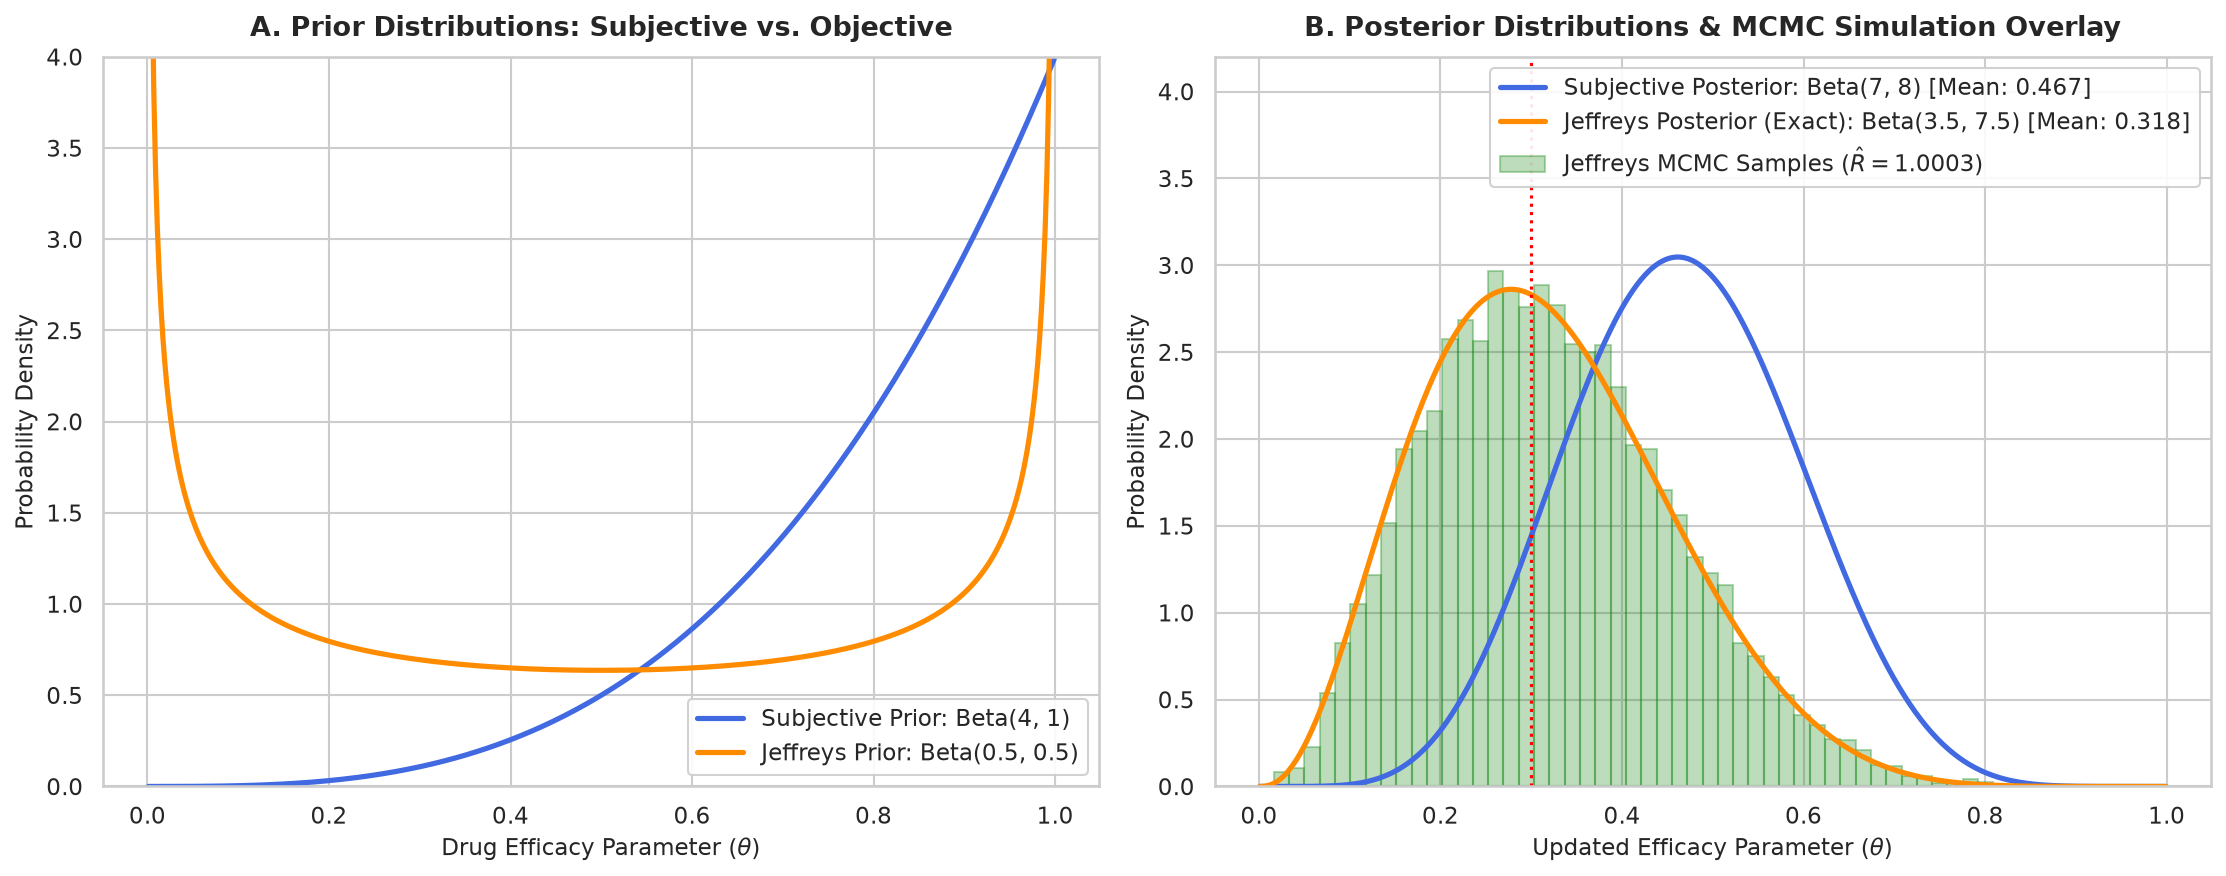

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import beta, binom

# Set plotting style
sns.set_theme(style='whitegrid', palette='colorblind', font='DejaVu Sans')
plt.rcParams['figure.dpi'] = 150


# 1. Experimental Setup & Analytical Posteriors

# Data: y = 3 successes out of N = 10 trials
N = 10
y = 3

# Subjective Prior: Beta(alpha=4, beta=1)
alpha_sub, beta_sub = 4, 1
# Analytical Subjective Posterior: Beta(alpha + y, beta + N - y) -> Beta(7, 8)
alpha_sub_post, beta_sub_post = alpha_sub + y, beta_sub + N - y

# Jeffreys Prior: Beta(alpha=0.5, beta=0.5)
alpha_jef, beta_jef = 0.5, 0.5
# Analytical Jeffreys Posterior: Beta(alpha + y, beta + N - y) -> Beta(3.5, 7.5)
alpha_jef_post, beta_jef_post = alpha_jef + y, beta_jef + N - y



# 2. Custom Metropolis-Hastings Sampler (for Jeffreys non-conjugate path)

def unnormalized_posterior(theta, y, N, alpha, beta_param):
    """Computes the unnormalized posterior probability (Likelihood * Prior)"""
    if theta < 0.0 or theta > 1.0:
        return 0.0
    # Likelihood
    likelihood = binom.pmf(y, N, theta)
    # Prior (Beta distribution PDF)
    prior = beta.pdf(theta, alpha, beta_param)
    return likelihood * prior

def run_metropolis_hastings(y, N, alpha, beta_param, num_samples=15000, burn_in=5000, start_val=0.5):
    """Runs a single Metropolis-Hastings chain from a given starting value"""
    chain = []
    current_theta = start_val
    current_prob = unnormalized_posterior(current_theta, y, N, alpha, beta_param)
    
    # Proposal distribution standard deviation
    proposal_std = 0.1
    
    for _ in range(num_samples):
        # Propose a new state from a Gaussian centered at current state
        proposed_theta = np.random.normal(current_theta, proposal_std)
        proposed_prob = unnormalized_posterior(proposed_theta, y, N, alpha, beta_param)
        
        # Calculate acceptance ratio
        if current_prob == 0.0:
            acceptance_ratio = 1.0
        else:
            acceptance_ratio = min(1.0, proposed_prob / current_prob)
        
        # Accept or reject
        if np.random.uniform(0, 1) < acceptance_ratio:
            current_theta = proposed_theta
            current_prob = proposed_prob
            
        chain.append(current_theta)
        
    # Return chain after discarding the burn-in period
    return np.array(chain[burn_in:])



# 3. Gelman-Rubin Split R-hat Diagnostic from First Principles

def compute_r_hat(chain1, chain2):
    """
    Computes the Gelman-Rubin (R-hat) convergence diagnostic for 2 chains
    using the split chain method.
    """
    # Split each chain in half to create 4 sub-chains (improves diagnostic)
    half1 = len(chain1) // 2
    half2 = len(chain2) // 2
    
    sub_chains = [
        chain1[:half1], chain1[half1:],
        chain2[:half2], chain2[half2:]
    ]
    
    M = len(sub_chains) # Number of sub-chains (4)
    N_samples = len(sub_chains[0]) # Length of each sub-chain
    
    # Mean of each chain
    chain_means = [np.mean(c) for c in sub_chains]
    # Overall mean
    overall_mean = np.mean(chain_means)
    
    # Between-chain variance (B)
    B = (N_samples / (M - 1)) * np.sum((chain_means - overall_mean)**2)
    
    # Within-chain variance (W)
    chain_vars = [np.var(c, ddof=1) for c in sub_chains]
    W = np.mean(chain_vars)
    
    # Marginal posterior variance estimate
    var_plus = ((N_samples - 1) / N_samples) * W + (1 / N_samples) * B
    
    # R-hat
    r_hat = np.sqrt(var_plus / W)
    return r_hat


# Run 2 independent MCMC chains starting from different points
np.random.seed(42)  # For reproducible results
chain1 = run_metropolis_hastings(y, N, alpha_jef, beta_jef, start_val=0.1)
chain2 = run_metropolis_hastings(y, N, alpha_jef, beta_jef, start_val=0.9)

# Compute R-hat convergence diagnostic
r_hat_value = compute_r_hat(chain1, chain2)
print(f"Gelman-Rubin diagnostic (R-hat): {r_hat_value:.6f}")



# 4. Publication-Quality Visualization

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

theta_grid = np.linspace(0.001, 0.999, 500)

# PANEL A: PRIORS

# Plot Subjective Prior
ax1.plot(theta_grid, beta.pdf(theta_grid, alpha_sub, beta_sub), 
         label=f'Subjective Prior: Beta({alpha_sub}, {beta_sub})', 
         color='royalblue', linewidth=2.5)
# Plot Jeffreys Prior
ax1.plot(theta_grid, beta.pdf(theta_grid, alpha_jef, beta_jef), 
         label=f'Jeffreys Prior: Beta({alpha_jef}, {beta_jef})', 
         color='darkorange', linewidth=2.5)

ax1.set_title("A. Prior Distributions: Subjective vs. Objective", fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel(r"Drug Efficacy Parameter ($\theta$)", fontsize=11)
ax1.set_ylabel("Probability Density", fontsize=11)
ax1.set_ylim(0, 4)
ax1.legend(frameon=True, facecolor='white', framealpha=0.9)

# PANEL B: POSTERIORS

# Plot Subjective Analytical Posterior
ax2.plot(theta_grid, beta.pdf(theta_grid, alpha_sub_post, beta_sub_post), 
         label=f'Subjective Posterior: Beta({alpha_sub_post}, {beta_sub_post}) [Mean: {alpha_sub_post/(alpha_sub_post+beta_sub_post):.3f}]', 
         color='royalblue', linewidth=2.5)

# Plot Jeffreys Analytical Posterior
ax2.plot(theta_grid, beta.pdf(theta_grid, alpha_jef_post, beta_jef_post), 
         label=f'Jeffreys Posterior (Exact): Beta({alpha_jef_post:.1f}, {beta_jef_post:.1f}) [Mean: {alpha_jef_post/(alpha_jef_post+beta_jef_post):.3f}]', 
         color='darkorange', linewidth=2.5)

# Overlay Jeffreys MCMC Sampling Histogram
combined_mcmc_samples = np.concatenate([chain1, chain2])
ax2.hist(combined_mcmc_samples, density=True, alpha=0.3, color='forestgreen', edgecolor='green',
         bins=50, label=f'Jeffreys MCMC Samples ($\hat{{R}} = {r_hat_value:.4f}$)')

ax2.set_title("B. Posterior Distributions & MCMC Simulation Overlay", fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel(r"Updated Efficacy Parameter ($\theta$)", fontsize=11)
ax2.set_ylabel("Probability Density", fontsize=11)
ax2.set_ylim(0, 4.2)
ax2.legend(frameon=True, facecolor='white', framealpha=0.9)

# Add a text annotation showing the empirical trial success rate
ax2.axvline(0.3, color='red', linestyle=':', linewidth=1.5, label='Sample Success Proportion (3/10)')

plt.tight_layout()
plt.show()
